In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

In [6]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11


In [7]:
from google.colab import files
import pandas as pd

print("\n Upload your CSV file...")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
print(f"\nDataset shape: {df.shape}")
df.head()


 Upload your CSV file...


Saving AIBL.csv to AIBL (1).csv

Dataset shape: (820, 36)


,APGEN1,APGEN2,CDGLOBAL,AXT117,BAT126,HMT3,HMT7,HMT13,HMT40,HMT100,...,LIMMTOTAL,LDELTOTAL,DXCURREN,DXNORM,DXMCI,DXAD,PTGENDER,Examyear,APTyear,PTDOBYear
0,4,4,1.0,6.99,345.619,4.29,4.8,164,15.0,34.9,...,3,0.0,0,0,0,1,1,2007,2007,1925
1,4,3,0.5,1.51,585.520,4.42,3.2,250,15.0,33.9,...,10,0.0,0,0,1,0,1,2008,2008,1930
2,4,3,0.0,2.84,838.974,3.92,5.1,226,12.9,32.9,...,18,19.0,1,1,0,0,2,2008,2008,1941
3,3,3,0.0,2.01,521.817,4.15,5.0,258,13.7,33.1,...,14,14.0,1,1,0,0,1,2008,2008,1934
4,3,2,0.5,3.59,290.049,4.23,6.9,269,13.5,32.0,...,7,2.0,0,0,1,0,2,2012,2012,1929


In [8]:
df['DX'] = np.select(
    [df['DXNORM'] == 1, df['DXMCI'] == 1, df['DXAD'] == 1],
    [0, 1, 2]  # 0=Normal, 1=MCI, 2=Alzheimer's
)

print(f"\n Class distribution:")
print(df['DX'].value_counts())
print(f"  - Normal (0): {(df['DX']==0).sum()}")
print(f"  - MCI (1): {(df['DX']==1).sum()}")
print(f"  - Alzheimer's (2): {(df['DX']==2).sum()}")



 Class distribution:
DX
0    592
1    133
2     95
Name: count, dtype: int64
  - Normal (0): 592
  - MCI (1): 133
  - Alzheimer's (2): 95


In [9]:
df = df.drop(columns=['DXNORM', 'DXMCI', 'DXAD', 'DXCURREN'])

In [10]:
df['Age'] = df['Examyear'] - df['PTDOBYear']
df = df.drop(columns=['Examyear', 'APTyear', 'PTDOBYear'])


In [11]:
df['PTGENDER'] = df['PTGENDER'].map({1: 0, 2: 1})

In [12]:
df = df[(df['Age'] >= 50) & (df['Age'] <= 100)]
print(f"Dataset shape after age filtering: {df.shape}")


Dataset shape after age filtering: (819, 31)


In [13]:
def analyze_features(df, features, group_name, y):
    """
    Analyze feature importance using Random Forest
    """
    print("\n" + "="*70)
    print(f" {group_name.upper()} FEATURES ANALYSIS")
    print("="*70)

    # Check missing values
    missing = df[features].isna().sum()
    print(f"\n Missing values:")
    for feat, count in missing.items():
        if count > 0:
            print(f"  - {feat}: {count}")

    # Drop missing values
    df_clean = df.dropna(subset=features)
    print(f"\n Samples after removing NaN: {len(df_clean)}")

    # Apply log transform for imaging features if needed
    if group_name == "Imaging":
        skewed_features = ['BAT126', 'HMT13', 'RCT6', 'RCT11', 'RCT20', 'RCT392']
        for col in skewed_features:
            if col in features:
                df_clean[col] = np.log1p(np.abs(df_clean[col]))
        print(" Applied log transform to skewed features")

    # Normalize features
    scaler = StandardScaler()
    X = scaler.fit_transform(df_clean[features])
    y_clean = df_clean[y]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_clean, test_size=0.2, random_state=42, stratify=y_clean
    )

    # Train Random Forest
    print("\n Training Random Forest...")
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)

    rf_accuracy = rf_model.score(X_test, y_test)
    print(f" Random Forest Accuracy: {rf_accuracy:.4f}")

    # Train LASSO (Logistic Regression with L1)
    print("\n Training LASSO (L1 Regularization)...")
    lasso_model = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        C=0.1,
        max_iter=1000,
        random_state=42
    )
    lasso_model.fit(X_train, y_train)

    lasso_accuracy = lasso_model.score(X_test, y_test)
    print(f" LASSO Accuracy: {lasso_accuracy:.4f}")

    # Get feature importance from both models
    rf_importance = rf_model.feature_importances_
    lasso_coef = np.abs(lasso_model.coef_[0])

    importance_df = pd.DataFrame({
        'Feature': features,
        'RF_Importance': rf_importance,
        'LASSO_Importance': lasso_coef / lasso_coef.sum()  # Normalize
    })

    # Combined importance (average)
    importance_df['Combined_Importance'] = (
        importance_df['RF_Importance'] + importance_df['LASSO_Importance']
    ) / 2

    importance_df = importance_df.sort_values('Combined_Importance', ascending=False)

    print(f"\n Feature Importance (Combined RF + LASSO):")
    for idx, row in importance_df.iterrows():
        print(f"  {row['Feature']:15s}: RF={row['RF_Importance']:.4f} | LASSO={row['LASSO_Importance']:.4f} | Combined={row['Combined_Importance']:.4f}")

    # Plot feature importance comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, max(6, len(features)*0.4)))

    # Random Forest
    colors_rf = sns.color_palette("viridis", len(features))
    axes[0].barh(importance_df['Feature'], importance_df['RF_Importance'], color=colors_rf)
    axes[0].set_xlabel('Importance', fontsize=11, fontweight='bold')
    axes[0].set_title('Random Forest', fontsize=12, fontweight='bold')
    axes[0].invert_yaxis()
    for i, (idx, row) in enumerate(importance_df.iterrows()):
        axes[0].text(row['RF_Importance'], i, f" {row['RF_Importance']:.3f}",
                    va='center', fontsize=9)

    # LASSO
    colors_lasso = sns.color_palette("rocket", len(features))
    axes[1].barh(importance_df['Feature'], importance_df['LASSO_Importance'], color=colors_lasso)
    axes[1].set_xlabel('Importance', fontsize=11, fontweight='bold')
    axes[1].set_title('LASSO (L1)', fontsize=12, fontweight='bold')
    axes[1].invert_yaxis()
    axes[1].set_yticklabels([])  # Hide labels on middle plot
    for i, (idx, row) in enumerate(importance_df.iterrows()):
        axes[1].text(row['LASSO_Importance'], i, f" {row['LASSO_Importance']:.3f}",
                    va='center', fontsize=9)

    # Combined
    colors_combined = sns.color_palette("mako", len(features))
    axes[2].barh(importance_df['Feature'], importance_df['Combined_Importance'], color=colors_combined)
    axes[2].set_xlabel('Importance', fontsize=11, fontweight='bold')
    axes[2].set_title('Combined (RF + LASSO)', fontsize=12, fontweight='bold')
    axes[2].invert_yaxis()
    axes[2].set_yticklabels([])  # Hide labels on right plot
    for i, (idx, row) in enumerate(importance_df.iterrows()):
        axes[2].text(row['Combined_Importance'], i, f" {row['Combined_Importance']:.3f}",
                    va='center', fontsize=9)

    fig.suptitle(f'{group_name} Feature Importance Comparison',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{group_name.lower()}_importance_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    return importance_df, rf_accuracy, lasso_accuracy



 CLINICAL FEATURES ANALYSIS

 Missing values:

 Samples after removing NaN: 819

 Training Random Forest...
 Random Forest Accuracy: 0.9024

 Training LASSO (L1 Regularization)...
 LASSO Accuracy: 0.9146

 Feature Importance (Combined RF + LASSO):
  CDGLOBAL       : RF=0.4422 | LASSO=0.6454 | Combined=0.5438
  LDELTOTAL      : RF=0.2260 | LASSO=0.2421 | Combined=0.2340
  MMSCORE        : RF=0.2012 | LASSO=0.1126 | Combined=0.1569
  LIMMTOTAL      : RF=0.1306 | LASSO=0.0000 | Combined=0.0653


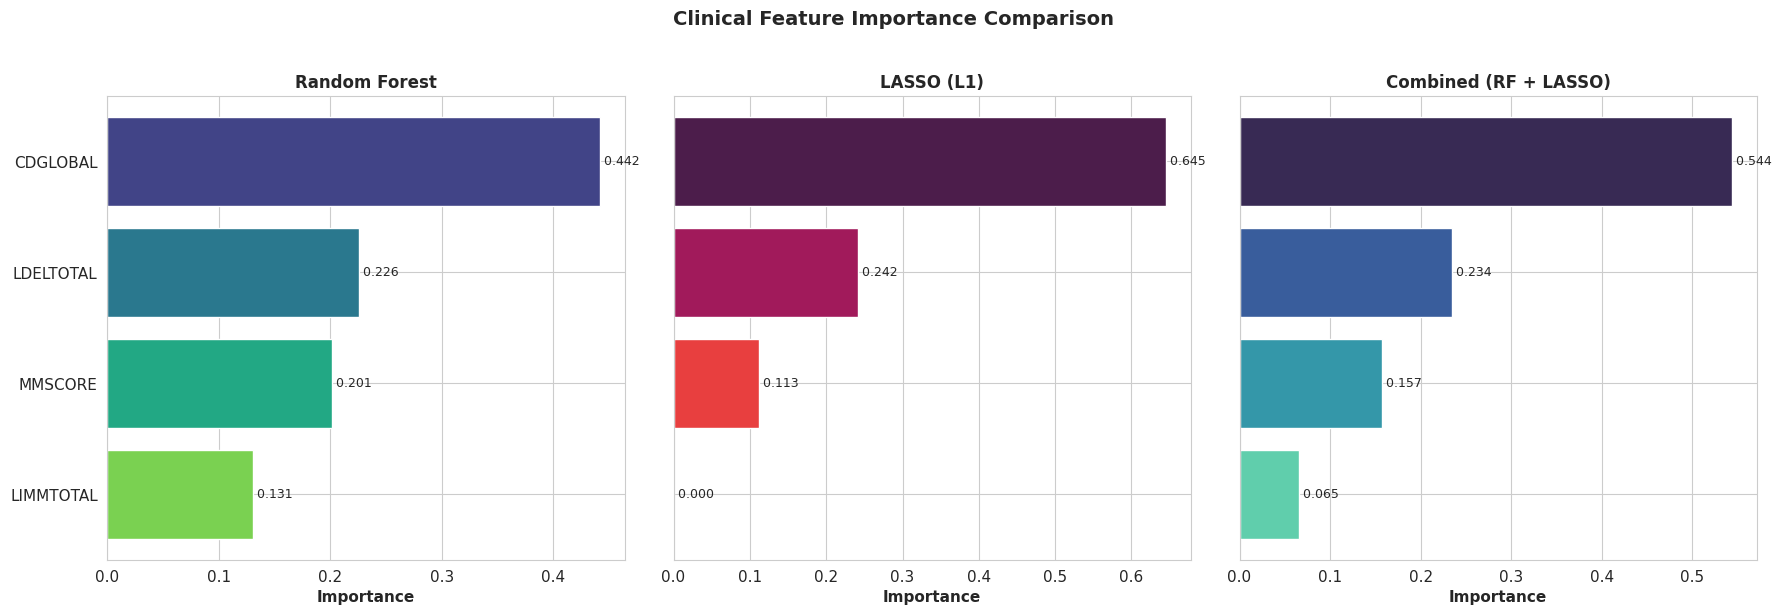

In [14]:
clinical_features = ['CDGLOBAL', 'MMSCORE', 'LIMMTOTAL', 'LDELTOTAL']
clinical_importance, clinical_rf_acc, clinical_lasso_acc = analyze_features(
    df, clinical_features, "Clinical", 'DX'
)


 DEMOGRAPHIC FEATURES ANALYSIS

 Missing values:

 Samples after removing NaN: 819

 Training Random Forest...
 Random Forest Accuracy: 0.7317

 Training LASSO (L1 Regularization)...
 LASSO Accuracy: 0.7195

 Feature Importance (Combined RF + LASSO):
  Age            : RF=0.9383 | LASSO=0.6865 | Combined=0.8124
  PTGENDER       : RF=0.0617 | LASSO=0.3135 | Combined=0.1876


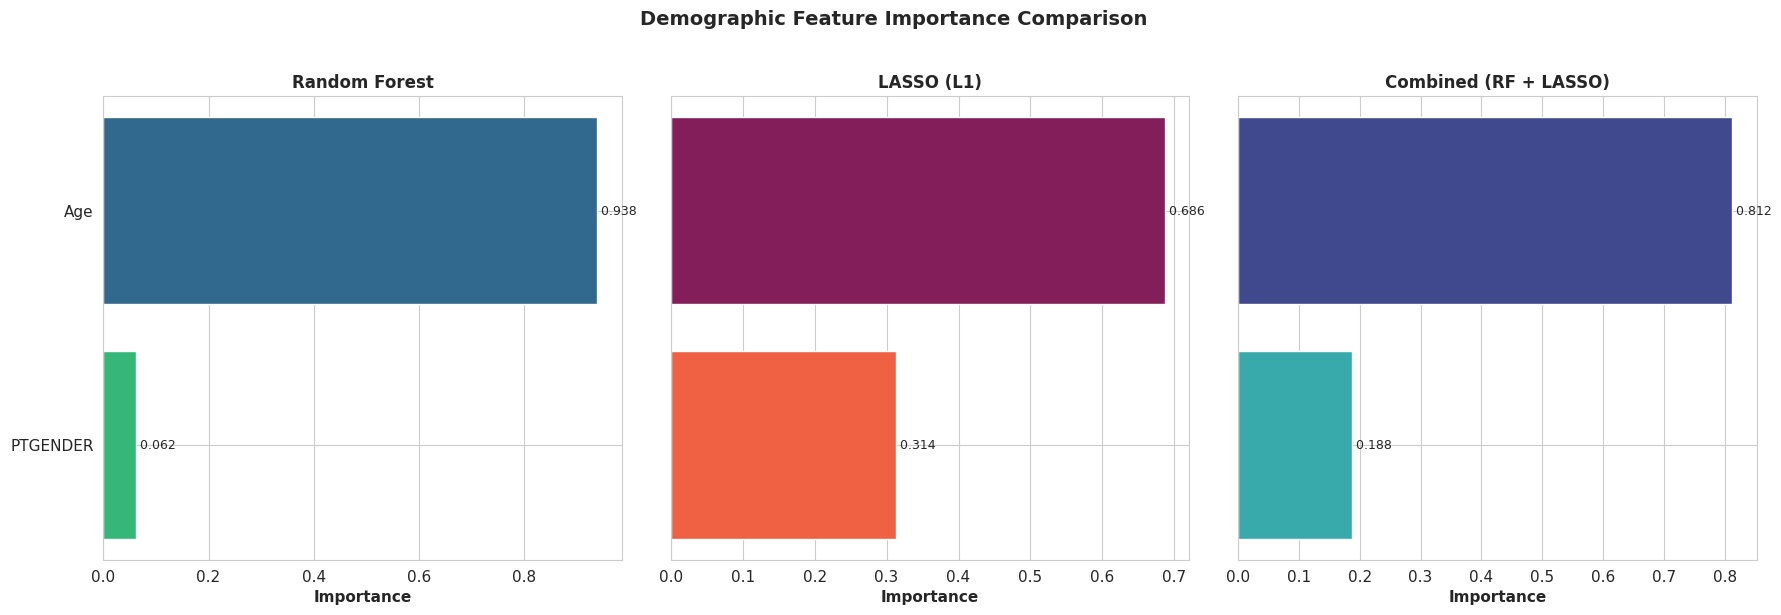

In [15]:
demographic_features = ['Age', 'PTGENDER']
demographic_importance, demographic_rf_acc, demographic_lasso_acc = analyze_features(
    df, demographic_features, "Demographic", 'DX'
)


 GENETIC FEATURES ANALYSIS

 Missing values:

 Samples after removing NaN: 819

 Training Random Forest...
 Random Forest Accuracy: 0.7195

 Training LASSO (L1 Regularization)...
 LASSO Accuracy: 0.7195

 Feature Importance (Combined RF + LASSO):
  APGEN1         : RF=0.6190 | LASSO=0.6425 | Combined=0.6308
  APGEN2         : RF=0.3810 | LASSO=0.3575 | Combined=0.3692


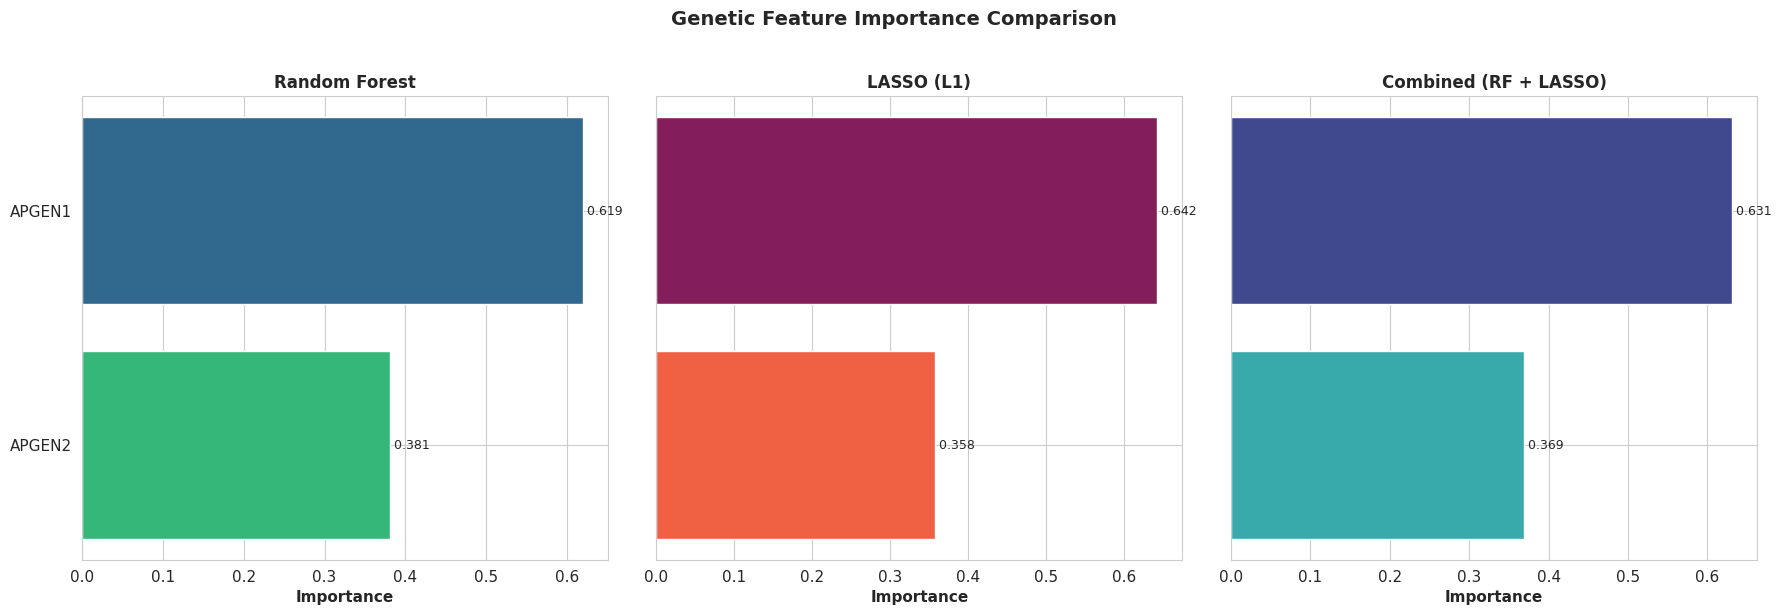

In [16]:
genetic_features = ['APGEN1', 'APGEN2']
genetic_importance, genetic_rf_acc, genetic_lasso_acc = analyze_features(
    df, genetic_features, "Genetic", 'DX'
)


 IMAGING FEATURES ANALYSIS

 Missing values:

 Samples after removing NaN: 819
 Applied log transform to skewed features

 Training Random Forest...
 Random Forest Accuracy: 0.7195

 Training LASSO (L1 Regularization)...
 LASSO Accuracy: 0.7195

 Feature Importance (Combined RF + LASSO):
  RCT392         : RF=0.0859 | LASSO=0.4046 | Combined=0.2453
  RCT6           : RF=0.0846 | LASSO=0.2511 | Combined=0.1679
  HMT7           : RF=0.0864 | LASSO=0.1573 | Combined=0.1219
  HMT102         : RF=0.0667 | LASSO=0.1049 | Combined=0.0858
  BAT126         : RF=0.0966 | LASSO=0.0466 | Combined=0.0716
  HMT100         : RF=0.0782 | LASSO=0.0353 | Combined=0.0568
  HMT13          : RF=0.0956 | LASSO=0.0000 | Combined=0.0478
  AXT117         : RF=0.0916 | LASSO=0.0000 | Combined=0.0458
  RCT20          : RF=0.0897 | LASSO=0.0000 | Combined=0.0449
  RCT11          : RF=0.0780 | LASSO=0.0000 | Combined=0.0390
  HMT3           : RF=0.0778 | LASSO=0.0000 | Combined=0.0389
  HMT40          : RF=0.0690

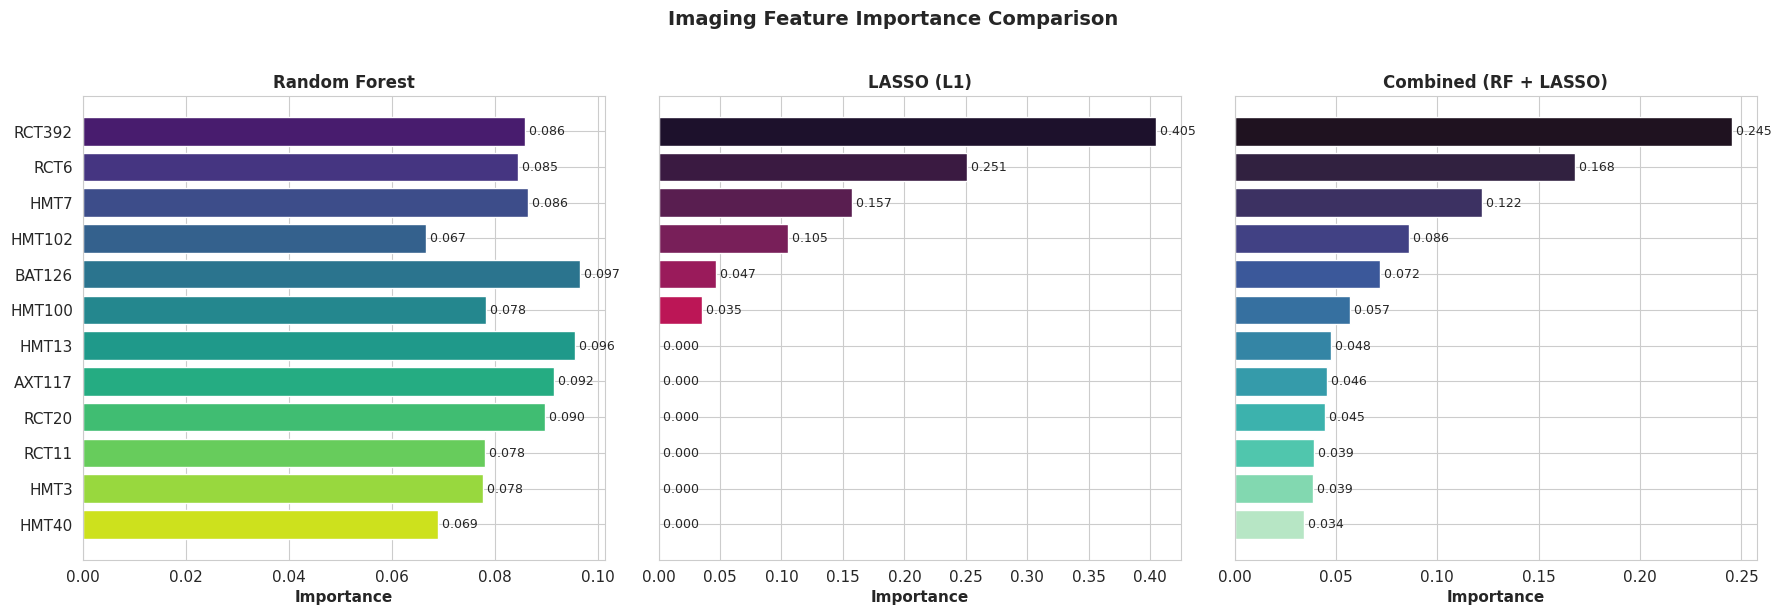

In [17]:
imaging_features = ['AXT117', 'BAT126', 'HMT3', 'HMT7', 'HMT13', 'HMT40',
                   'HMT100', 'HMT102', 'RCT6', 'RCT11', 'RCT20', 'RCT392']
imaging_importance, imaging_rf_acc, imaging_lasso_acc = analyze_features(
    df, imaging_features, "Imaging", 'DX'
)


 MEDICAL FEATURES ANALYSIS

 Missing values:

 Samples after removing NaN: 819

 Training Random Forest...
 Random Forest Accuracy: 0.7073

 Training LASSO (L1 Regularization)...
 LASSO Accuracy: 0.7195

 Feature Importance (Combined RF + LASSO):
  MH16SMOK       : RF=0.1347 | LASSO=0.3312 | Combined=0.2329
  MH2NEURL       : RF=0.1236 | LASSO=0.2927 | Combined=0.2081
  MH8MUSCL       : RF=0.1150 | LASSO=0.1279 | Combined=0.1214
  MHPSYCH        : RF=0.0998 | LASSO=0.1234 | Combined=0.1116
  MH9ENDO        : RF=0.1054 | LASSO=0.0575 | Combined=0.0815
  MH4CARD        : RF=0.1150 | LASSO=0.0091 | Combined=0.0621
  MH12RENA       : RF=0.0569 | LASSO=0.0583 | Combined=0.0576
  MH10GAST       : RF=0.1072 | LASSO=0.0000 | Combined=0.0536
  MH17MALI       : RF=0.0967 | LASSO=0.0000 | Combined=0.0483
  MH6HEPAT       : RF=0.0458 | LASSO=0.0000 | Combined=0.0229


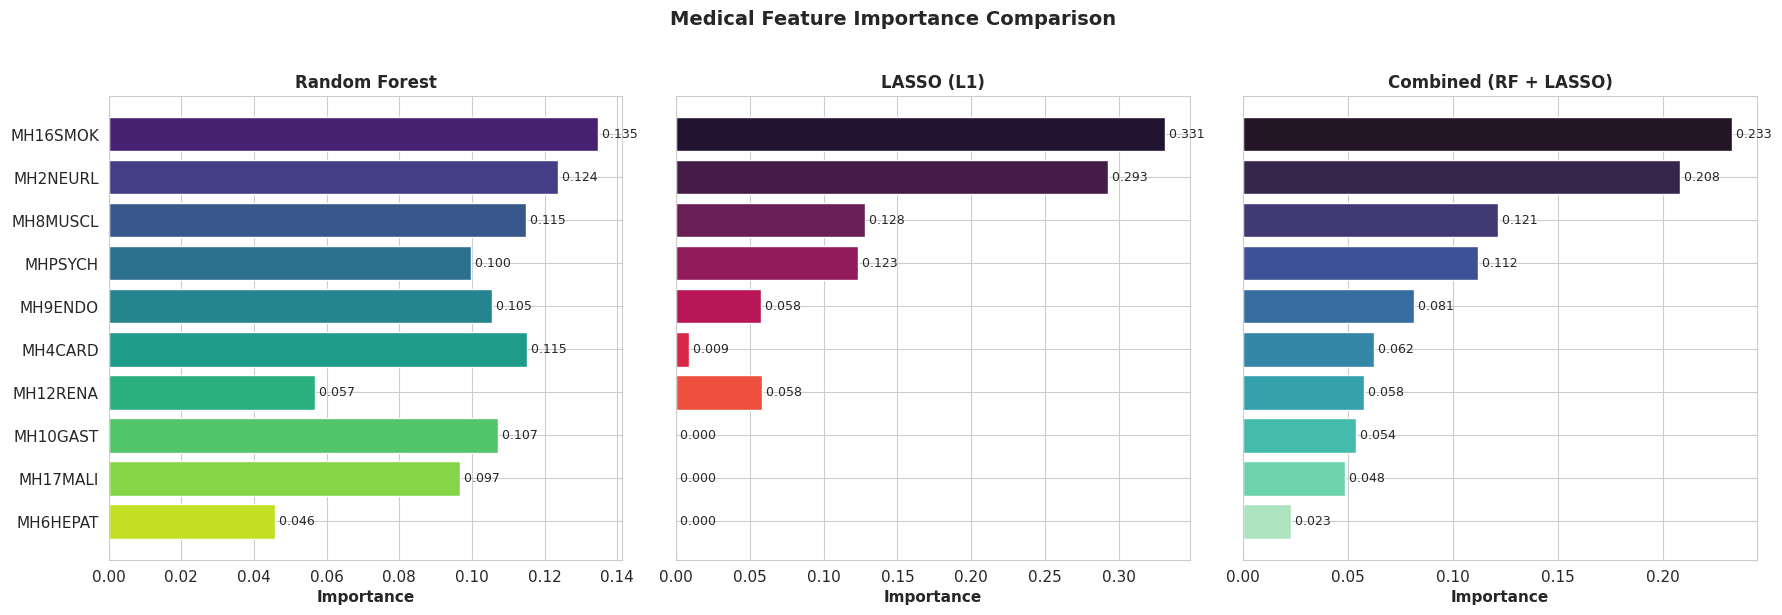

In [18]:
medical_features = ['MHPSYCH', 'MH2NEURL', 'MH4CARD', 'MH6HEPAT', 'MH8MUSCL',
                   'MH9ENDO', 'MH10GAST', 'MH12RENA', 'MH16SMOK', 'MH17MALI']
medical_importance, medical_rf_acc, medical_lasso_acc = analyze_features(
    df, medical_features, "Medical", 'DX'
)

In [19]:
print("\n" + "="*70)
print(" SUMMARY - ACCURACY BY FEATURE GROUP")
print("="*70)

summary_data = {
    'Feature Group': ['Clinical', 'Demographic', 'Genetic', 'Imaging', 'Medical'],
    'RF_Accuracy': [clinical_rf_acc, demographic_rf_acc, genetic_rf_acc,
                    imaging_rf_acc, medical_rf_acc],
    'LASSO_Accuracy': [clinical_lasso_acc, demographic_lasso_acc, genetic_lasso_acc,
                       imaging_lasso_acc, medical_lasso_acc],
    'Num Features': [len(clinical_features), len(demographic_features),
                     len(genetic_features), len(imaging_features), len(medical_features)]
}

summary_df = pd.DataFrame(summary_data)
summary_df['Avg_Accuracy'] = (summary_df['RF_Accuracy'] + summary_df['LASSO_Accuracy']) / 2
summary_df = summary_df.sort_values('Avg_Accuracy', ascending=False)

print("\n" + summary_df.to_string(index=False))



 SUMMARY - ACCURACY BY FEATURE GROUP

Feature Group  RF_Accuracy  LASSO_Accuracy  Num Features  Avg_Accuracy
     Clinical     0.902439        0.914634             4      0.908537
  Demographic     0.731707        0.719512             2      0.725610
      Genetic     0.719512        0.719512             2      0.719512
      Imaging     0.719512        0.719512            12      0.719512
      Medical     0.707317        0.719512            10      0.713415


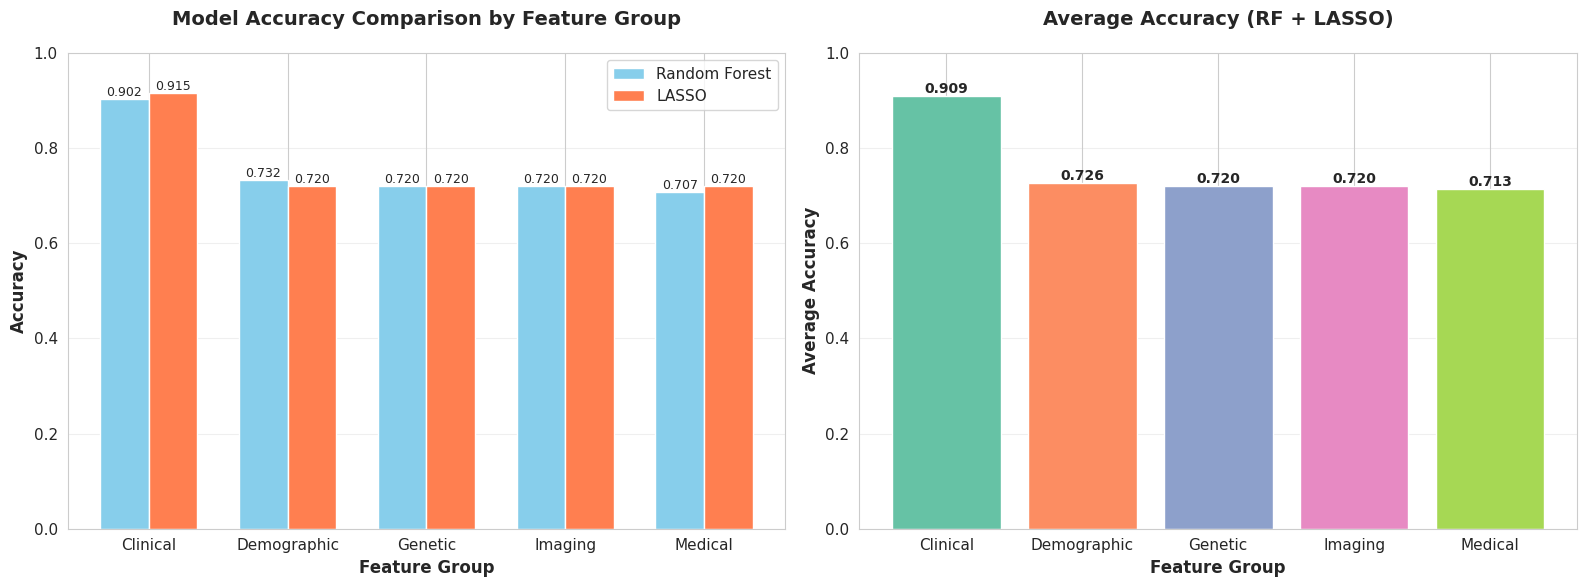

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Grouped bar chart
x = np.arange(len(summary_df))
width = 0.35

bars1 = ax1.bar(x - width/2, summary_df['RF_Accuracy'], width,
                label='Random Forest', color='skyblue')
bars2 = ax1.bar(x + width/2, summary_df['LASSO_Accuracy'], width,
                label='LASSO', color='coral')

ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_xlabel('Feature Group', fontsize=12, fontweight='bold')
ax1.set_title('Model Accuracy Comparison by Feature Group',
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(summary_df['Feature Group'])
ax1.set_ylim([0, 1])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Average accuracy
colors = sns.color_palette("Set2", len(summary_df))
bars3 = ax2.bar(summary_df['Feature Group'], summary_df['Avg_Accuracy'], color=colors)
ax2.set_ylabel('Average Accuracy', fontsize=12, fontweight='bold')
ax2.set_xlabel('Feature Group', fontsize=12, fontweight='bold')
ax2.set_title('Average Accuracy (RF + LASSO)',
              fontsize=14, fontweight='bold', pad=20)
ax2.set_ylim([0, 1])
ax2.grid(axis='y', alpha=0.3)

for bar in bars3:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
print("\n" + "="*70)
print(" FINAL MODEL - XGBOOST WITH SELECTED FEATURES")
print("="*70)

# Selected features (top performers from each group)
selected_features = [
    'CDGLOBAL',                                    # Clinical
    'Age', 'PTGENDER',                             # Demographic
    'APGEN1', 'APGEN2',                            # Genetic
    'RCT392', 'RCT6', 'RCT20', 'HMT3', 'HMT40',   # Imaging
    'MH12RENA', 'MH2NEURL', 'MH16SMOK'            # Medical
]

print(f"\n Selected Features ({len(selected_features)}):")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i:2d}. {feat}")



 FINAL MODEL - XGBOOST WITH SELECTED FEATURES

 Selected Features (13):
   1. CDGLOBAL
   2. Age
   3. PTGENDER
   4. APGEN1
   5. APGEN2
   6. RCT392
   7. RCT6
   8. RCT20
   9. HMT3
  10. HMT40
  11. MH12RENA
  12. MH2NEURL
  13. MH16SMOK


In [22]:
df_final = df.dropna(subset=selected_features).copy()
print(f"\n Final dataset shape: {df_final.shape}")



 Final dataset shape: (819, 31)


In [23]:
# Apply log transform to imaging features
print("\n Applying preprocessing:")
imaging_skewed = ['BAT126', 'HMT13', 'RCT6', 'RCT11', 'RCT20', 'RCT392']
for col in imaging_skewed:
    if col in selected_features:
        df_final[col] = np.log1p(np.abs(df_final[col]))
        print(f"   Log transform applied to {col}")



 Applying preprocessing:
   Log transform applied to RCT6
   Log transform applied to RCT20
   Log transform applied to RCT392


In [24]:
# Normalize using StandardScaler
print("\n Normalizing features (StandardScaler)...")
scaler_final = StandardScaler()
X_final = scaler_final.fit_transform(df_final[selected_features])
y_final = df_final['DX']

# Print normalization stats
print(f"   Features normalized to mean=0, std=1")
print(f"   Shape after normalization: {X_final.shape}")


 Normalizing features (StandardScaler)...
   Features normalized to mean=0, std=1
   Shape after normalization: (819, 13)


In [25]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

print(f"\n Data Split:")
print(f"  - Training set: {X_train.shape}")
print(f"  - Test set: {X_test.shape}")


 Data Split:
  - Training set: (655, 13)
  - Test set: (164, 13)


In [26]:
print(f"\n Normalization Verification:")
print(f"  - Training data mean: {X_train.mean():.6f}")
print(f"  - Training data std: {X_train.std():.6f}")
print(f"  - Test data mean: {X_test.mean():.6f}")
print(f"  - Test data std: {X_test.std():.6f}")



 Normalization Verification:
  - Training data mean: 0.009369
  - Training data std: 1.009293
  - Test data mean: -0.037418
  - Test data std: 0.961081


In [27]:
print("\n Training XGBoost model...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print("\n" + "="*70)
print(" FINAL MODEL PERFORMANCE")
print("="*70)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Difference: {abs(train_acc - test_acc):.4f}")

print("\n Classification Report:")
print(classification_report(y_test, y_pred_test,
                            target_names=['Normal', 'MCI', 'Alzheimer\'s']))



 Training XGBoost model...

 FINAL MODEL PERFORMANCE
Training Accuracy: 1.0000
Test Accuracy: 0.9329
Difference: 0.0671

 Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.99      0.97       118
         MCI       0.83      0.74      0.78        27
 Alzheimer's       0.89      0.84      0.86        19

    accuracy                           0.93       164
   macro avg       0.89      0.86      0.87       164
weighted avg       0.93      0.93      0.93       164



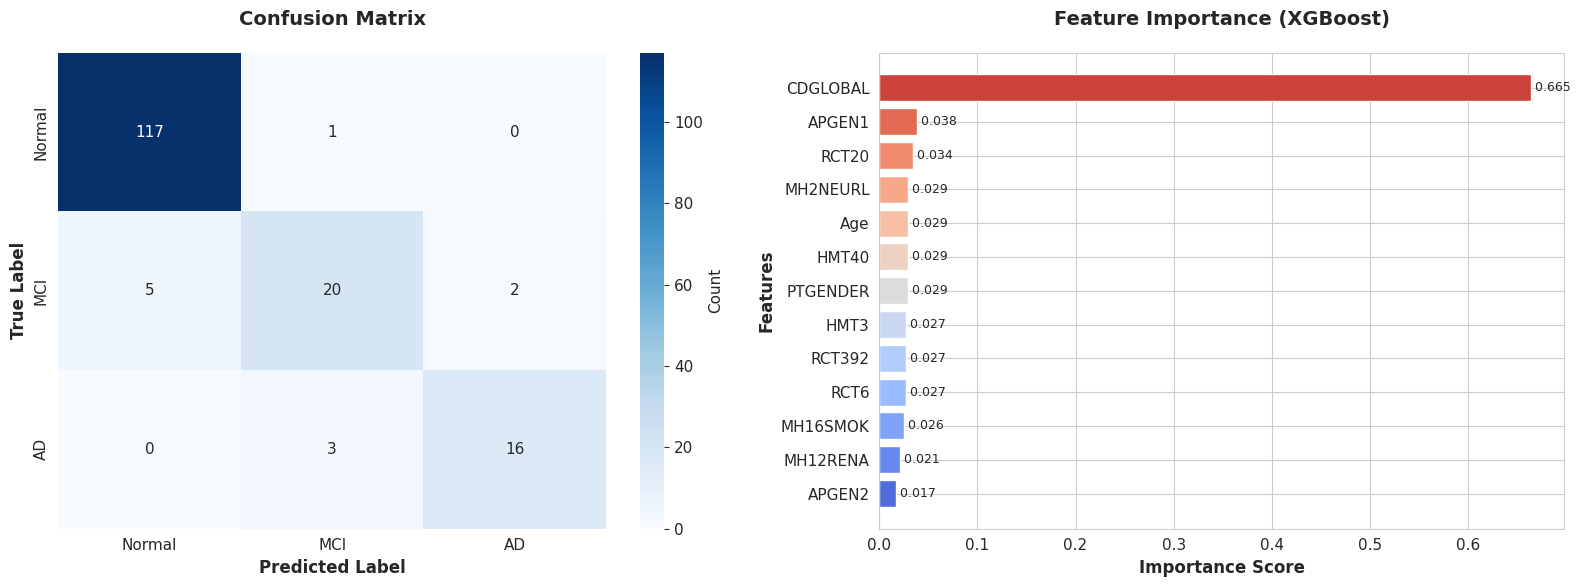

In [28]:
cm = confusion_matrix(y_test, y_pred_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Normal', 'MCI', 'AD'],
            yticklabels=['Normal', 'MCI', 'AD'],
            cbar_kws={'label': 'Count'})
ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=20)
ax1.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')

# Feature Importance (XGBoost)
feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

colors = sns.color_palette("coolwarm", len(feature_importance))
ax2.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors)
ax2.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax2.set_ylabel('Features', fontsize=12, fontweight='bold')
ax2.set_title('Feature Importance (XGBoost)', fontsize=14, fontweight='bold', pad=20)

# Add value labels
for i, (idx, row) in enumerate(feature_importance.iterrows()):
    ax2.text(row['Importance'], i, f" {row['Importance']:.3f}",
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('final_model_results.png', dpi=300, bbox_inches='tight')
plt.show()

In [29]:
"""
#
#
#
#
#
#
#
#
#
#
"""

'\n#\n#\n#\n#\n#\n#\n#\n#\n#\n#\n'

-----

# ***Cross validation and hyperparameter tuning***

In [30]:
# Import tools for hyperparameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import shap

In [31]:
# Cross-Validation evaluation for XGBoost
from sklearn.model_selection import cross_val_score

# Create XGBoost classifier with current best params
xgb_cv_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

# 5-fold cross-validation ا
cv_scores = cross_val_score(xgb_cv_model, X_final, y_final, cv=5, scoring='accuracy')

# Print results
print("Cross-validation scores (5 folds):", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Std of CV accuracy:", cv_scores.std())


Cross-validation scores (5 folds): [0.90853659 0.86585366 0.8597561  0.92682927 0.90184049]
Mean CV accuracy: 0.8925632201107288
Std of CV accuracy: 0.025710255449744562


# ***Shap analysis***


 SHAP INTERPRETABILITY ANALYSIS
SHAP values shape: (164, 13, 3)

 SHAP analysis for class: Alzheimer's

 Generating SHAP summary bar plot...


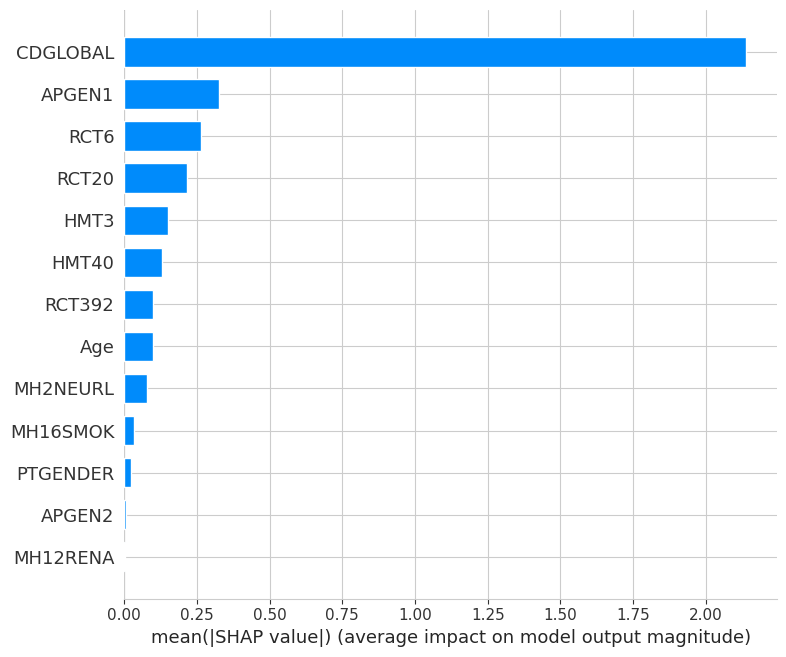


 Generating SHAP beeswarm plot...


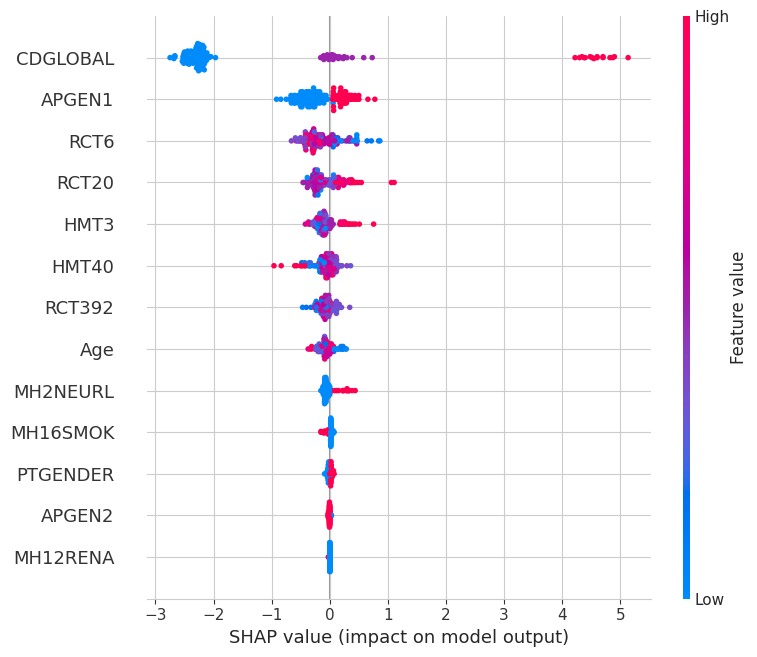


 Generating SHAP dependence plots:
  - APGEN1


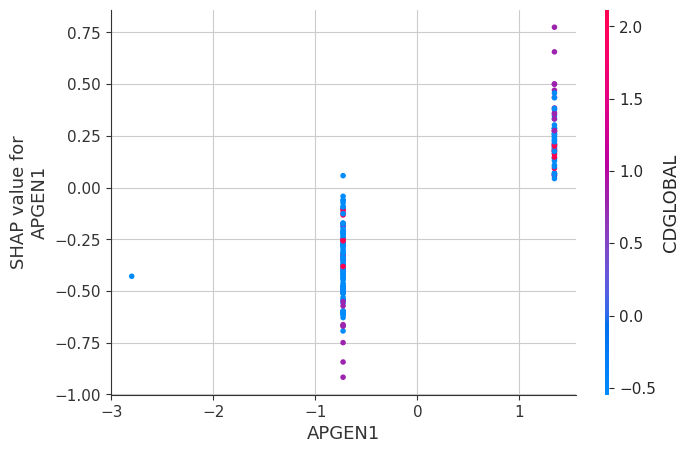

  - CDGLOBAL


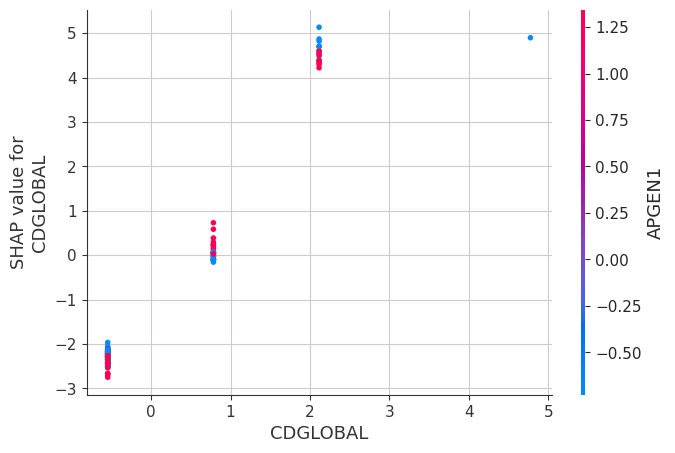


 SHAP analysis completed successfully.


In [37]:
import shap
import numpy as np
import matplotlib.pyplot as plt

print("\n" + "="*70)
print(" SHAP INTERPRETABILITY ANALYSIS")
print("="*70)

# Create explainer
explainer = shap.TreeExplainer(xgb_model)

# Use subset for speed
X_shap = X_test[:200]

# Compute SHAP values
shap_values = explainer.shap_values(X_shap)
print("SHAP values shape:", np.array(shap_values).shape)

# Select Alzheimer's class
class_idx = 2
class_name = "Alzheimer's"

print(f"\n SHAP analysis for class: {class_name}")

# Extract SHAP values for one class
class_shap_values = shap_values[:, :, class_idx]

print("\n Generating SHAP summary bar plot...")

shap.summary_plot(
    class_shap_values,
    X_shap,
    feature_names=selected_features,
    plot_type="bar"
)

print("\n Generating SHAP beeswarm plot...")

shap.summary_plot(
    class_shap_values,
    X_shap,
    feature_names=selected_features
)

# Mean absolute SHAP importance
mean_shap = np.abs(class_shap_values).mean(axis=0)

# Top 2 important features
top_features_idx = np.argsort(mean_shap)[-2:]
top_features = [selected_features[i] for i in top_features_idx]

print("\n Generating SHAP dependence plots:")

for feat in top_features:
    print(f"  - {feat}")

    shap.dependence_plot(
        feat,
        class_shap_values,
        X_shap,
        feature_names=selected_features
    )

print("\n SHAP analysis completed successfully.")

In [34]:
#hyperparameter tuning
from scipy.stats import randint, uniform
print("\n" + "="*70)
print(" HYPERPARAMETER TUNING - XGBOOST")
print("="*70)

param_dist = {
    'n_estimators': randint(100, 400),
    'max_depth': randint(3, 8),
    'learning_rate': uniform(0.01, 0.1),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'gamma': uniform(0, 0.5)
}

xgb_base = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring='accuracy',
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("\n Best Hyperparameters:")
for k, v in random_search.best_params_.items():
    print(f"  - {k}: {v}")

print(f"\n Best Cross-Validated Accuracy: {random_search.best_score_:.4f}")

best_xgb_model = random_search.best_estimator_

y_pred_test = best_xgb_model.predict(X_test)
tuned_test_acc = accuracy_score(y_test, y_pred_test)

print(f"\n Tuned Model Test Accuracy: {tuned_test_acc:.4f}")


 HYPERPARAMETER TUNING - XGBOOST
Fitting 5 folds for each of 30 candidates, totalling 150 fits

 Best Hyperparameters:
  - colsample_bytree: 0.8199582915145766
  - gamma: 0.023332831606807714
  - learning_rate: 0.10737555188414592
  - max_depth: 5
  - n_estimators: 154
  - subsample: 0.9949692657420364

 Best Cross-Validated Accuracy: 0.8977

 Tuned Model Test Accuracy: 0.9268


# ***Macro F1 + Balanced Accuracy***

In [35]:
from sklearn.metrics import f1_score, balanced_accuracy_score

f1 = f1_score(y_test, y_pred_test, average='macro')
bal_acc = balanced_accuracy_score(y_test, y_pred_test)

print(f"Macro F1-score: {f1:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")


Macro F1-score: 0.8653
Balanced Accuracy: 0.8458
